# Analysis of the imaging experiment
mouse name: 067 (or 057?)  
task: NearFarLong  
experimentalist: Snezana Raus-Balind  

### 1. Load the necessary object class
We use a custom-made class, ImagingSessionData, that will contain all behavioral and imaging data

In [1]:
from abmice.ImageAnal import ImagingSessionData
import os
import pathlib
import numpy as np

### 2. Tell python where the data is
The required file structure is the following:  
- All data should be in the data folder
- Within the data folder separate subfolders are needed for each mouse. Folder name starts with the **name** of the mouse.
- For each mouse there should be at least two folders: one for the **imaging** data and one for the **behavioral** data.
- The behavioral folder is named as `MouseName_TaskName` - so we need a separate folder for each different task
- The behavioral log files are in separate subfolders named by the experiment's start time within the behavioral folder - e.g. `2021-02-03_10-15-50`
- The imaging folder is named as `MouseName_imaging`
- The suite2p imaging files are also in separate folders for each experiment below the imaging folder. 

In [2]:
datapath = pathlib.Path(os.getcwd()) / 'data' #current working directory - look for data and strings here!
date_time = '2021-10-31_10-31-32' # date and time of the imaging session
name = 'KS030' # mouse name
task = 'NearFarLong' # task name

## locate the suite2p folder
suite2p_folder = datapath / (name + '_imaging') / 'KS030_103121'

## the name and location of the imaging log file
imaging_logfile_name = str(suite2p_folder / 'KS030_TSeries-10312021-1017-001.xml')

## the name and location of the trigger voltage file
TRIGGER_VOLTAGE_FILENAME = str(suite2p_folder / 'KS030_TSeries-10312021-1017-001_Cycle00001_VoltageRecording_001.csv')

trigger_voltage_path = suite2p_folder / 'KS030_TSeries-10312021-1017-001_Cycle00001_VoltageRecording_001.csv'
action_log_file_path = datapath / 'KS030_NearFarLong' / date_time / '2021-10-31_10-31-32_KS030_NearFarLong_UserActionLog.txt'
trigger_log_file_path = datapath / 'KS030_NearFarLong' / date_time / '2021-10-31_10-31-32_KS030_NearFarLong_TriggerLog.txt'
data_log_file_path = datapath / 'KS030_NearFarLong' / date_time / '2021-10-31_10-31-32_KS030_NearFarLong_ExpStateMashineLog.txt'

F_all_path = suite2p_folder / 'F.npy'
spikes_all_path = suite2p_folder / 'spks.npy'
is_cell_path = suite2p_folder / 'iscell.npy'


### 3. Load all the data - this takes ~20 secs in my computer
Python looks for the data in the specified folders. It loads the behavioral data (position, lick and rewards) as well as the imaging data. It calculates the activity of the cells as a function of position in the different corridors and calculates their spatial tuning measures and corridor selectivity.  
The name of the object that contains all the data is `D1` here - Data 1.

In [3]:
# 3. load all the data - this taks ~20 secs in my computer
D1 = ImagingSessionData(
    str(datapath),
    date_time,
    name,
    task,
    str(suite2p_folder),
    imaging_logfile_name,
    TRIGGER_VOLTAGE_FILENAME,
    trigger_voltage_path=trigger_voltage_path,
    action_log_file_path=action_log_file_path,
    trigger_log_file_path=trigger_log_file_path,
    F_all_path=F_all_path,
    spikes_all_path=spikes_all_path,
    is_cell_path=is_cell_path,
    data_log_file_path=data_log_file_path,
)


relevant behavior located, lap time of the first frame: 382.32759
   slight warning - testing some late candidates failed
suite2p data loaded
corrected offset: 382.3235900000001 voltage_delay: 0.00399999999990541
single-plane
suite2p time axis loaded
calculating dF/F and SNR...
SNR done
dF/F calculated for cell ROI-s
ExpStateMachineLog time interval > 1s:  1  times
length of frame_times: 17994
length of frame_laps: 17994
shape of dF_F: (1367, 17994)
Late-start lap found, first position: 4093.11 in lap 41 in corridor 15
Early end lap found, last position: 3554.19 in lap 117 in corridor 14
Short lap found, we have total  419 position bins recorded by the ExpStateMachine in a lap before lap 134 in corridor 14
laps with im data:  [ 42  43  44  45  46  47  48  49  50  51  52  53  54  55  56  57  58  59
  60  61  62  63  64  65  66  67  68  69  70  71  72  73  74  75  76  77
  78  79  80  81  82  83  84  85  86  87  88  89  90  91  92  93  94  95
  96  97  98  99 100 101 102 103 104 105 106 

The behavior is divided into laps (trials or runs). You can check the **number of laps** and which lap is associated with imaging data in the following way:

In [4]:
# print(D1.n_laps)
# print(D1.i_Laps_ImData)


So we have 229 laps and laps 83-138 contain imaging data.  
### 4. Plotting the behavioral data
You can plot the behavioral data of the session:

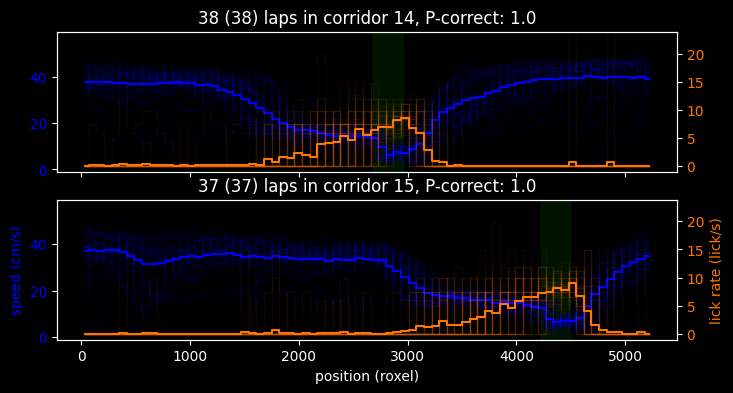

In [5]:
#D1.plot_session()
D1.plot_session(selected_laps=D1.i_Laps_ImData)

### 5. Plot the ratemaps
First, we plot the ratemaps of some neurons. There are several options - selecting the cells, sorting and normalising the ratemaps.
- selection: here we select all active cells (activity in at least 20% of laps), but any other selection criteria 
- sorting: place fields can be sorted by either corridors
- place cells can be normalised - so the peak has the same height

In [6]:
D1.ratemaps[1].shape

[lap.get_max_velocity() for lap in D1.get_imaged_laps()]

[np.float64(36.81122422828797),
 np.float64(32.56268280799178),
 np.float64(32.00722839427757),
 np.float64(33.629677149432965),
 np.float64(32.81981168819723),
 np.float64(31.94340811456288),
 np.float64(34.96237314794893),
 np.float64(36.1550648879526),
 np.float64(42.36185218811501),
 np.float64(42.302941276235416),
 np.float64(41.03072489014253),
 np.float64(41.71086018322249),
 np.float64(43.18576764648877),
 np.float64(42.53022257301061),
 np.float64(38.55029488042424),
 np.float64(42.3698563774024),
 np.float64(35.68928564111721),
 np.float64(36.68558016197447),
 np.float64(44.52147293702456),
 np.float64(43.58934797401278),
 np.float64(42.11718539386141),
 np.float64(37.70089550684559),
 np.float64(40.991953378573896),
 np.float64(40.34586449044901),
 np.float64(39.1420141814153),
 np.float64(43.03938119255477),
 np.float64(43.70435647369057),
 np.float64(45.5131158002253),
 np.float64(45.03793052589057),
 np.float64(44.732557021534944),
 np.float64(39.75725607952362),
 np.floa

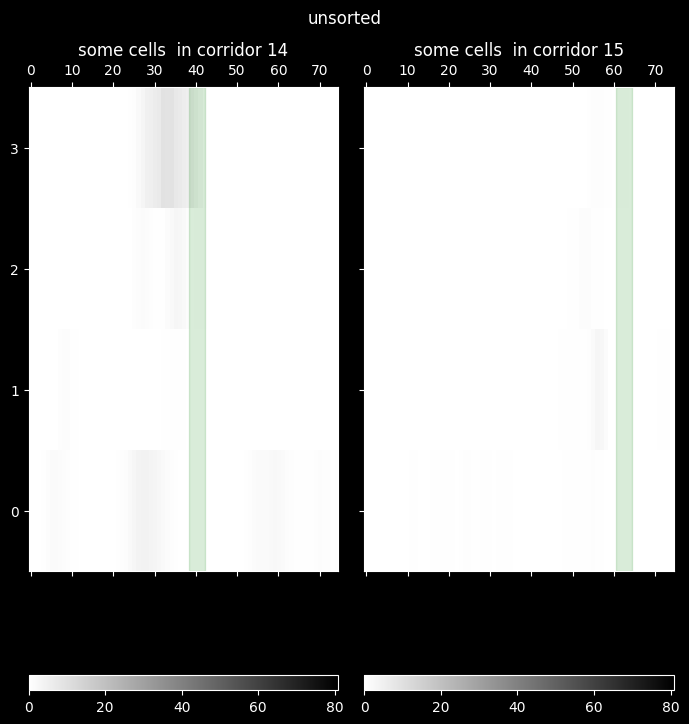

array([0, 1, 2, 3])

In [7]:
cellids = np.arange(4)
D1.plot_ratemaps(cellids = cellids, sorted=False, normalized=False)

### 6. Plot the spatial properies of the neurons

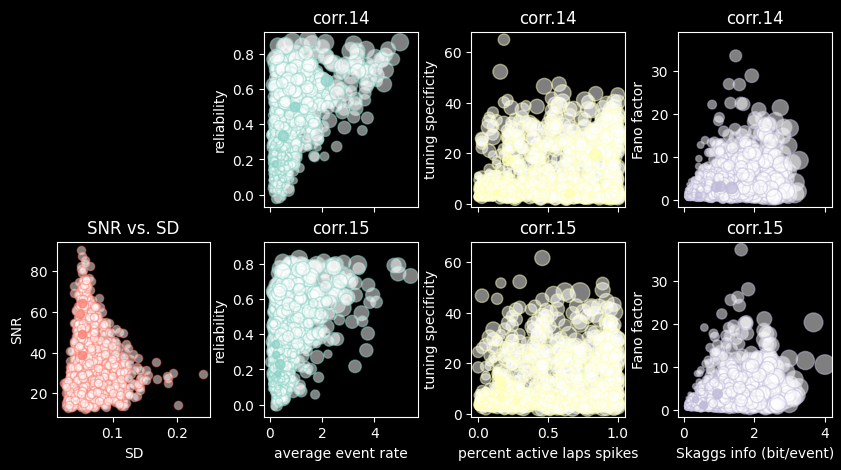

In [8]:
D1.plot_properties(cellids=cellids, interactive=False)

### 7. Calculate significance of tuning by shuffling the imaging data 

In [21]:
D1.calc_shuffle(cellids, 1000, 'shift')


/Users/krajnyi/dev/abmice/data/KS030_imaging/KS030_103121analysed_data/shuffle_stats_n1000_mode_shift.csv successfully loaded


In [16]:
D1.get_tuning_parameters()


TuningParameters(skaggs=[array([0, 2, 3]), array([0, 1, 3])], ts=[array([2, 3]), array([0, 1, 2])], reli=[array([0, 1, 2, 3]), array([0, 1, 2, 3])])

In [17]:
D1.get_total_cell_number()

1367

In [ ]:
D1.get_selective_cells()


### 6.  Plot the activity lap by lap
We can also plot the lap by lap activity of a selected cell. Again, there are several options, but the simplest is to plot the rate as a function of position.

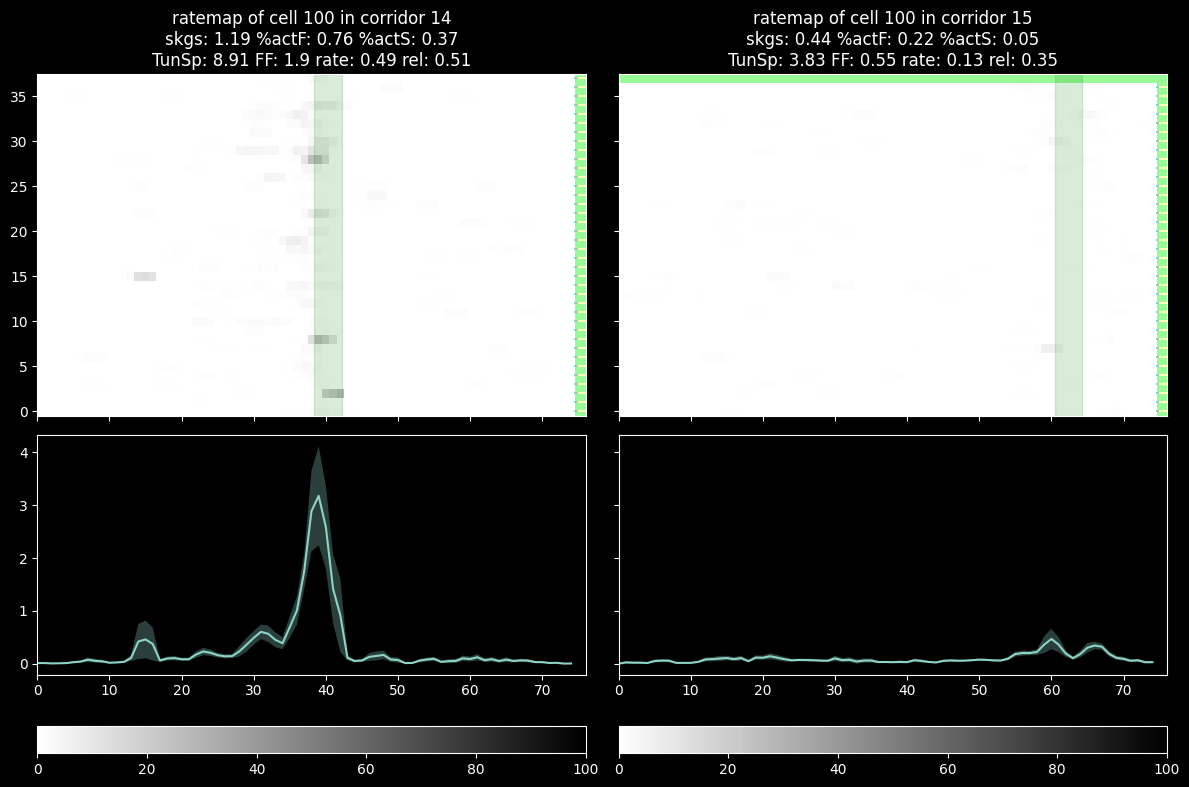

In [18]:
D1.plot_cell_laps(cellid=100, signal='rate') ## look at lap 20

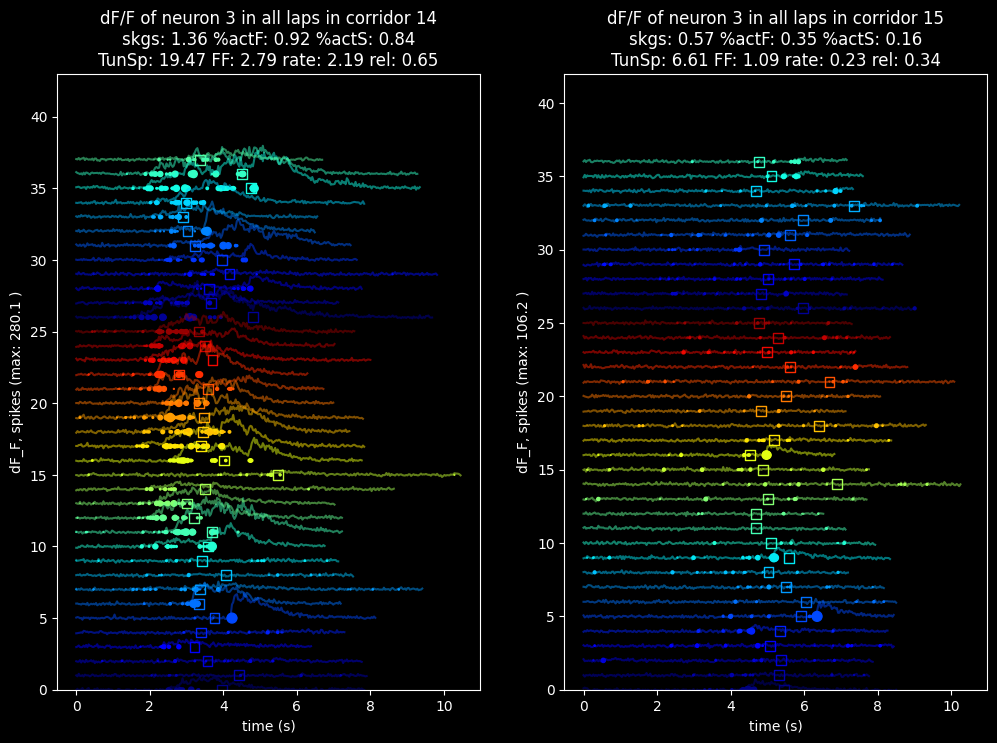

In [12]:
D1.plot_cell_laps(cellid=3, signal='dF') ## look at lap 20